In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [2]:
a, b, c, d = 1.0, -6.0, 11.0, -6.0

def cubic_function(x):
    return a * x**3 + b * x**2 + c * x + d


In [3]:
class RootFinderNet(nn.Module):
    def __init__(self, init_x: float):
        super().__init__()
        self.fc1 = nn.Linear(1, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.register_buffer("dummy_input", torch.tensor([[1.0]]))

        with torch.no_grad():
            self.fc1.weight.zero_()
            self.fc1.bias.fill_(1.0)
            self.fc2.weight.fill_(0.0)
            self.fc2.bias.fill_(init_x)

    def forward(self):
        h = self.relu(self.fc1(self.dummy_input))
        x = self.fc2(h)
        return x


In [4]:
def find_root(init_guess, epochs=5000, lr=0.0015, momentum=0.7, clip_norm=5.0):
    net = RootFinderNet(init_guess)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum)

    for epoch in range(epochs):
        optimizer.zero_grad()
        x = net()
        residual = cubic_function(x)
        loss = residual.pow(2).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), clip_norm)
        optimizer.step()

    return net().item()


In [5]:
initial_guesses = [-2.0, 0.5, 1.7, 2.4, 4.0]
found_roots = []

for guess in initial_guesses:
    root_val = find_root(guess)
    found_roots.append(root_val)
    print(f"Starting guess {guess:5.1f} -> Root: {root_val:.4f}, f(root) = {cubic_function(root_val):.6f}")

unique_roots = []
for r in found_roots:
    if not any(abs(r - ur) < 1e-2 for ur in unique_roots):
        unique_roots.append(r)

print("\nAll roots found:", [round(r, 4) for r in found_roots])
print("Unique roots:", sorted(round(r, 4) for r in unique_roots))


Starting guess  -2.0 -> Root: 1.0000, f(root) = -0.000000


Starting guess   0.5 -> Root: 1.0000, f(root) = 0.000000


Starting guess   1.7 -> Root: 2.0000, f(root) = 0.000000


Starting guess   2.4 -> Root: 2.0000, f(root) = -0.000001


Starting guess   4.0 -> Root: 3.0000, f(root) = 0.000000

All roots found: [1.0, 1.0, 2.0, 2.0, 3.0]
Unique roots: [1.0, 2.0, 3.0]


In [6]:
coeffs = [a, b, c, d]
exact_roots = np.roots(coeffs)
print("Exact roots (NumPy):        ", sorted(np.round(exact_roots.real, 4)))
print("SGD/ReLU model-found roots: ", sorted(round(r, 4) for r in unique_roots))

max_err = max(abs(cubic_function(r)) for r in unique_roots)
print(f"\nMax |f(root)| over found roots: {max_err:.2e}")
assert max_err < 1e-2
print("PASS: solver found all real roots of the cubic equation.")


Exact roots (NumPy):         [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
SGD/ReLU model-found roots:  [1.0, 2.0, 3.0]

Max |f(root)| over found roots: 4.77e-07
PASS: solver found all real roots of the cubic equation.


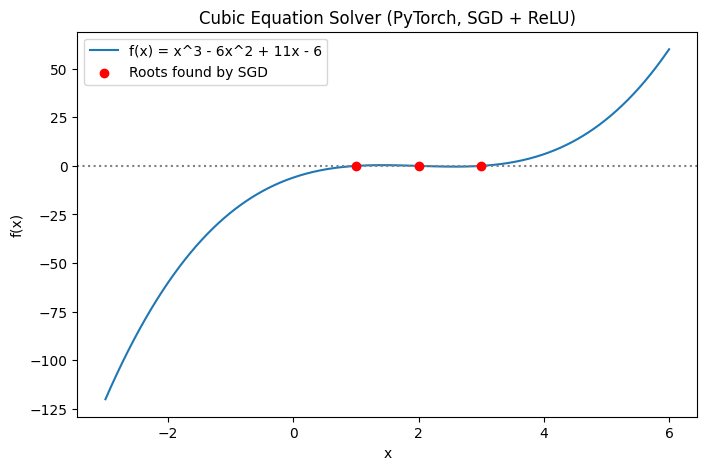

In [7]:
xs = np.linspace(-3, 6, 400)
ys = cubic_function(xs)

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label="f(x) = x^3 - 6x^2 + 11x - 6")
plt.axhline(0, color='gray', linestyle=':')
plt.scatter(unique_roots, [cubic_function(r) for r in unique_roots],
            color='red', zorder=5, label="Roots found by SGD")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Cubic Equation Solver (PyTorch, SGD + ReLU)")
plt.legend()
plt.show()
